/tmp/ipython-input-2565669892.py:46: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2565669892.py:49: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


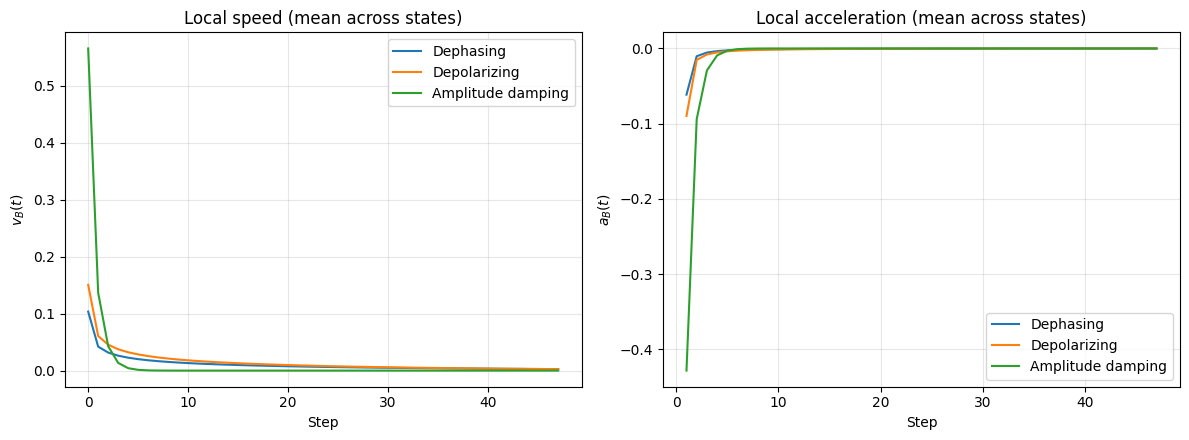

/tmp/ipython-input-2565669892.py:46: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2565669892.py:49: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


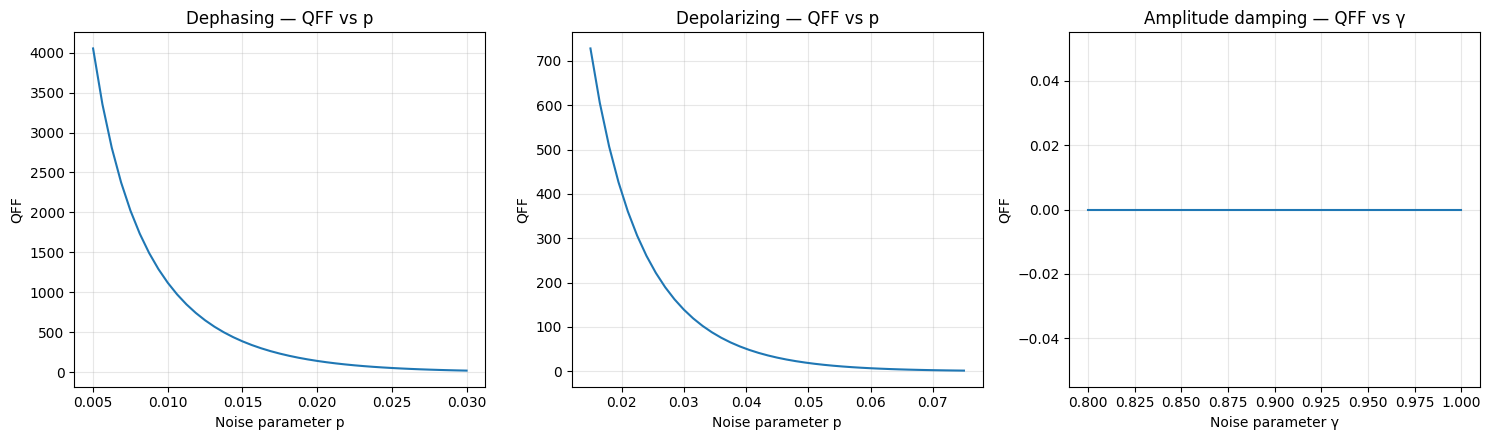

0

In [1]:
import numpy as np
from numpy.random import default_rng
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from io import BytesIO

# -----------------------------
# Configuration
# -----------------------------
N_STATES    = 30          # 6 cardinal states + 24 random
DEPTH       = 48          # steps per trajectory
GRID_NPTS   = 41          # number of QFF sweep points
DELTA_PARAM = 1e-3        # symmetric finite difference step δ
RNG         = default_rng(123)
eps         = 1e-9

# Parameter ranges (NOT rescaled)
RANGE_DEPH = (0.005, 0.03)    # p (dephasing)
RANGE_DEPO = (0.015, 0.075)   # p (depolarizing)
RANGE_AD   = (0.80, 1.00)     # γ (amplitude damping)

# -----------------------------
# Linear algebra + qubit channels
# -----------------------------
I2 = np.eye(2, dtype=np.complex128)
X  = np.array([[0, 1],[1, 0]], dtype=np.complex128)
Y  = np.array([[0, -1j],[1j, 0]], dtype=np.complex128)
Z  = np.array([[1, 0],[0, -1]], dtype=np.complex128)

def pure_to_rho(psi):
    psi = np.asarray(psi, dtype=np.complex128).reshape(2,1)
    psi /= np.linalg.norm(psi)
    return psi @ psi.conj().T

def haar_random_pure_qubit(n: int, rng=RNG):
    """Generate n Haar-random pure qubit states (density matrices)."""
    states = []
    for _ in range(n):
        z = rng.normal(size=2) + 1j * rng.normal(size=2)
        psi = z / np.linalg.norm(z)
        states.append(pure_to_rho(psi))
    return states

def fidelity(rho, sigma):
    """Uhlmann fidelity F(rho, sigma)."""
    sr = sqrtm(rho)
    inner = sr @ sigma @ sr
    inner = (inner + inner.conj().T)/2
    root = sqrtm(inner)
    return float(np.clip(np.real(np.trace(root))**2, 0.0, 1.0))

def bures_distance(rho, sigma):
    """Bures distance D_B(rho, sigma)."""
    F = fidelity(rho, sigma)
    return float(np.sqrt(max(0.0, 2.0*(1.0 - np.sqrt(F)))))

def apply_kraus(rho, Ks):
    """Apply a Kraus map to rho."""
    out = np.zeros((2,2), dtype=np.complex128)
    for K in Ks:
        out += K @ rho @ K.conj().T
    out = (out + out.conj().T)/2
    tr = np.real(np.trace(out))
    return out/tr if tr > 0 else I2/2

# --- Channels ---
def dephasing_kraus(p):
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Z]

def depolarizing_kraus(p):
    a0 = np.sqrt(1 - 3*p/4); a = np.sqrt(p/4)
    return [a0*I2, a*X, a*Y, a*Z]

def amplitude_damping_kraus(g):
    g = float(np.clip(g, 0.0, 1.0 - eps))  # avoid negative sqrt
    K0 = np.array([[1,0],[0,np.sqrt(1-g)]], dtype=np.complex128)
    K1 = np.array([[0,np.sqrt(g)],[0,0]], dtype=np.complex128)
    return [K0, K1]

def trajectory(rho0, kraus_fn, param, depth):
    """Generate the discrete trajectory ρ_t applying the channel repeatedly."""
    traj = [rho0]
    Ks = kraus_fn(param)
    rho = rho0
    for _ in range(depth):
        rho = apply_kraus(rho, Ks)
        traj.append(rho)
    return traj

# -----------------------------
# Local metrics: v_B(t), a_B(t)
# -----------------------------
def bures_speed_series(traj):
    """Local speed v_B(t) = D_B(ρ_t, ρ_{t+1})."""
    return np.array([bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1)], dtype=float)

def bures_accel_series(v_series):
    """Local acceleration a_B(t) = v(t+1) − v(t)."""
    return np.diff(v_series) if len(v_series) > 1 else np.array([], dtype=float)

# -----------------------------
# QFF / QFI estimator (centered)
#   J(θ) ≈ D_B(ρ_{θ-δ}, ρ_{θ+δ})² / δ²
# -----------------------------
def qff_for_state_centered(rho0, kraus_fn, theta, delta, depth):
    t1 = float(np.clip(theta - delta, 0.0, 1.0 - eps))
    t2 = float(np.clip(theta + delta, 0.0, 1.0 - eps))
    rho_m = trajectory(rho0, kraus_fn, t1, depth)[-1]
    rho_p = trajectory(rho0, kraus_fn, t2, depth)[-1]
    DB = bures_distance(rho_m, rho_p)
    return (DB*DB) / (delta**2)

def qff_sweep_centered(kraus_fn, pmin, pmax, npoints, depth, delta, states):
    """Compute mean QFF across states over a parameter sweep."""
    params = np.linspace(pmin, pmax, npoints)
    means  = [np.mean([qff_for_state_centered(rho0, kraus_fn, float(theta), delta, depth)
                       for rho0 in states]) for theta in params]
    return params, np.array(means, dtype=float)

# -----------------------------
# Input states
# -----------------------------
def sample_states(n_random: int, rng=RNG):
    """6 cardinal states + n_random Haar-random states."""
    CARDINAL = [
        pure_to_rho([1,0]), pure_to_rho([0,1]),
        pure_to_rho([1/np.sqrt(2),  1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2),  1j/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1j/np.sqrt(2)]),
    ]
    return CARDINAL + haar_random_pure_qubit(n_random, rng=rng)

states = sample_states(N_STATES - 6, rng=RNG)

# -----------------------------
# Utility: pick midpoint of parameter range
# -----------------------------
def pick_level_mid(rng_tuple):
    low, high = rng_tuple
    grid = np.linspace(low, high, GRID_NPTS)
    return grid[len(grid)//2]

lvl_deph = pick_level_mid(RANGE_DEPH)
lvl_depo = pick_level_mid(RANGE_DEPO)
lvl_ad   = pick_level_mid(RANGE_AD)

# -----------------------------
# ===== PANEL A: v_B(t) and a_B(t) =====
# -----------------------------
def collect_local_series(kraus_fn, level, depth, states):
    """Compute mean v_B(t) and a_B(t) across input states."""
    v_list, a_list = [], []
    for rho0 in states:
        traj = trajectory(rho0, kraus_fn, level, depth)
        v = bures_speed_series(traj)
        a = bures_accel_series(v)
        v_list.append(v); a_list.append(a)
    return np.mean(v_list, axis=0), np.mean(a_list, axis=0)

v_deph, a_deph = collect_local_series(dephasing_kraus,        lvl_deph, DEPTH, states)
v_depo, a_depo = collect_local_series(depolarizing_kraus,     lvl_depo, DEPTH, states)
v_ad,   a_ad   = collect_local_series(amplitude_damping_kraus, lvl_ad,   DEPTH, states)

t_v = np.arange(DEPTH, dtype=float)
t_a = np.arange(1, DEPTH, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# v_B(t)
axes[0].plot(t_v, v_deph, label="Dephasing")
axes[0].plot(t_v, v_depo, label="Depolarizing")
axes[0].plot(t_v, v_ad,   label="Amplitude damping")
axes[0].set_xlabel("Step")
axes[0].set_ylabel(r"$v_B(t)$")
axes[0].set_title("Local speed (mean across states)")
axes[0].grid(alpha=0.3)
axes[0].legend()

# a_B(t)
axes[1].plot(t_a, a_deph, label="Dephasing")
axes[1].plot(t_a, a_depo, label="Depolarizing")
axes[1].plot(t_a, a_ad,   label="Amplitude damping")
axes[1].set_xlabel("Step")
axes[1].set_ylabel(r"$a_B(t)$")
axes[1].set_title("Local acceleration (mean across states)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Save JPG in memory
buf_panelA = BytesIO()
fig.savefig(buf_panelA, dpi=300, format="jpg", bbox_inches="tight")
buf_panelA.seek(0)

# -----------------------------
# ===== PANEL B: QFF per channel =====
# -----------------------------
p_deph, qff_deph = qff_sweep_centered(dephasing_kraus,         *RANGE_DEPH, GRID_NPTS, DEPTH, DELTA_PARAM, states)
p_depo, qff_depo = qff_sweep_centered(depolarizing_kraus,      *RANGE_DEPO, GRID_NPTS, DEPTH, DELTA_PARAM, states)
p_ad,   qff_ad   = qff_sweep_centered(amplitude_damping_kraus, *RANGE_AD,   GRID_NPTS, DEPTH, DELTA_PARAM, states)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Dephasing
axes[0].plot(p_deph, qff_deph)
axes[0].set_xlabel("Noise parameter p")
axes[0].set_ylabel("QFF")
axes[0].set_title("Dephasing — QFF vs p")
axes[0].grid(alpha=0.3)

# Depolarizing
axes[1].plot(p_depo, qff_depo)
axes[1].set_xlabel("Noise parameter p")
axes[1].set_ylabel("QFF")
axes[1].set_title("Depolarizing — QFF vs p")
axes[1].grid(alpha=0.3)

# Amplitude damping
axes[2].plot(p_ad, qff_ad)
axes[2].set_xlabel("Noise parameter γ")
axes[2].set_ylabel("QFF")
axes[2].set_title("Amplitude damping — QFF vs γ")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Save JPG in memory
buf_panelB = BytesIO()
fig.savefig(buf_panelB, dpi=300, format="jpg", bbox_inches="tight")
buf_panelB.seek(0)
